In [15]:
import sys
sys.path.append('../src')

In [16]:
import numpy as np
from data_generator import build_cholesky_factor, sample_functions, compute_antiderivative
import matplotlib.pyplot as plt

In [17]:
n_fine = 500
ell = .2
rng= np.random.default_rng(40)
x_fine = np.linspace(0, 1, n_fine)

In [18]:
L = build_cholesky_factor(x_fine, ell)
u = sample_functions(L, 1000, rng)

In [19]:
integral = compute_antiderivative(u = u, x_fine=x_fine)

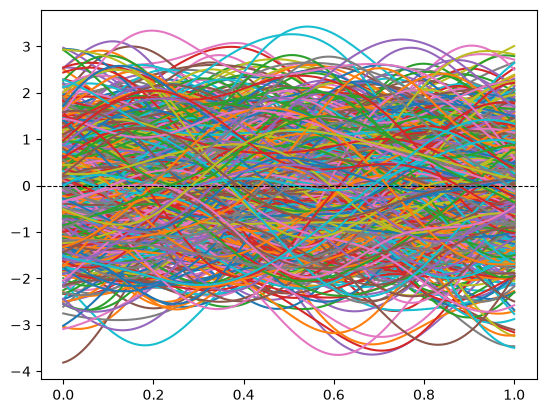

In [20]:
for i in range(u.shape[0]):
    plt.plot(x_fine, u[i])
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

In [21]:
from model import DeepONet
from sklearn.model_selection import train_test_split

In [22]:
u_train, u_test, s_train, s_test = train_test_split(u, integral)
y_query = x_fine.reshape(-1,1)


In [23]:
model = DeepONet(n_fine)
model.train()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=500, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=1, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): Tanh()
  )
)

## Training

In [24]:
import torch

u_t = torch.tensor(u_train, dtype=torch.float32)
s_t = torch.tensor(s_train, dtype=torch.float32)
y_t = torch.tensor(y_query, dtype=torch.float32)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

In [25]:
n_epochs = 20000
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = model(u_t, y_t)
    loss = loss_fn(pred, s_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 1000 == 0:
        print(f"epoch {epoch:4d}  loss {loss.item():.6f}")

epoch    0  loss 0.188184
epoch 1000  loss 0.001993
epoch 2000  loss 0.001003
epoch 3000  loss 0.002407
epoch 4000  loss 0.000243
epoch 5000  loss 0.000255
epoch 6000  loss 0.000233
epoch 7000  loss 0.000104
epoch 8000  loss 0.000079
epoch 9000  loss 0.000405
epoch 10000  loss 0.000350
epoch 11000  loss 0.000069
epoch 12000  loss 0.000060
epoch 13000  loss 0.000060
epoch 14000  loss 0.000289
epoch 15000  loss 0.000039
epoch 16000  loss 0.000459
epoch 17000  loss 0.000200
epoch 18000  loss 0.000173
epoch 19000  loss 0.000099


Text(0, 0.5, 'MSE loss')

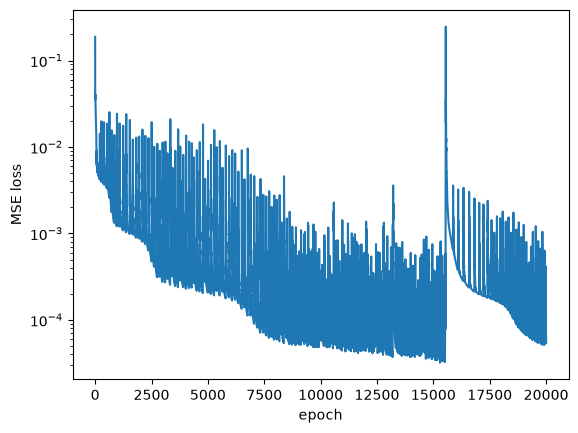

In [26]:
plt.plot(losses)
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE loss')

## Evaluate on held-out functions

test MSE: 0.000095


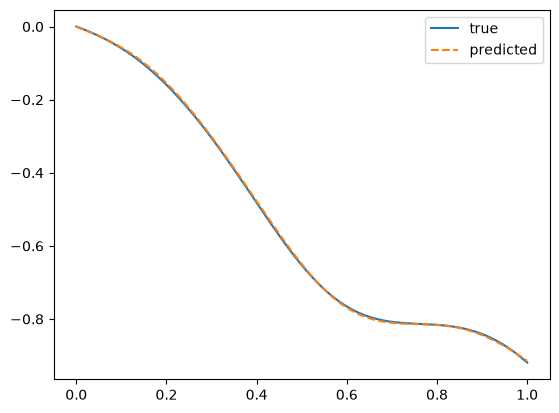

In [27]:
model.eval()
u_test_t = torch.tensor(u_test, dtype=torch.float32)
s_test_t = torch.tensor(s_test, dtype=torch.float32)

with torch.no_grad():
    pred_test = model(u_test_t, y_t)
    test_loss = loss_fn(pred_test, s_test_t)

print(f"test MSE: {test_loss.item():.6f}")

i = 0
plt.plot(x_fine, s_test[i], label='true')
plt.plot(x_fine, pred_test[i].numpy(), '--', label='predicted')
plt.legend()